# Predicting Employee Attrition Using Machine Learning
### A Data-Driven HR Retention System

**MSc Advanced Machine Learning — End-to-End Classification Project**

This notebook builds a complete, production-quality machine learning pipeline to predict whether an employee is likely to leave an organisation (`Attrition`: Yes/No). It covers data preprocessing, exploratory data analysis, feature engineering, model training, hyperparameter tuning, evaluation, explainability (SHAP), and final model persistence for deployment via a Streamlit application.

## 1. Import Libraries

In [1]:

# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, classification_report, roc_curve, precision_recall_curve
)

# Explainability
import shap

# Persistence
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully.")


All libraries imported successfully.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

In [2]:

DATA_PATH = "employee_attrition_dataset_10000.csv"
df = pd.read_csv(DATA_PATH)

print("First 5 rows:")
display(df.head())

print("\nShape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics (numerical features):")
display(df.describe())


First 5 rows:


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No



Shape of dataset: (10000, 26)

Column names:
['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department', 'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked', 'Attrition']

Data types:
Employee_ID                      int64
Age                              int64
Gender                             str
Marital_Status                     str
Department                         str
Job_Role                           str
Job_Level                        int64
Monthly_Income                   int64
Hourly_Rate                      int64
Years_at_Company                 int64
Years_in_Current_Role            int64


,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


## 3. Data Inspection

In [3]:

# Missing value analysis
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values in dataset:", df.isnull().sum().sum())
# Finding: The dataset contains no missing values across any of the 26 columns,
# so no imputation strategy is required.

# Duplicate check
n_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {n_duplicates}")
# Finding: No duplicate records were found, so no de-duplication is necessary.

# Unique values per column
print("\nUnique value counts per column:")
print(df.nunique())

# Target distribution
print("\nTarget variable (Attrition) distribution:")
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True).round(3) * 100)
# Finding: The target is imbalanced - approximately 80% "No" vs 20% "Yes".
# This informs our choice of stratified splitting and evaluation metrics
# (accuracy alone would be misleading, so ROC-AUC, precision, recall and F1
# are all reported for every model).


Missing values per column:
Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64

Total missing values in dataset: 0

Number of dup

## 4. Exploratory Data Analysis

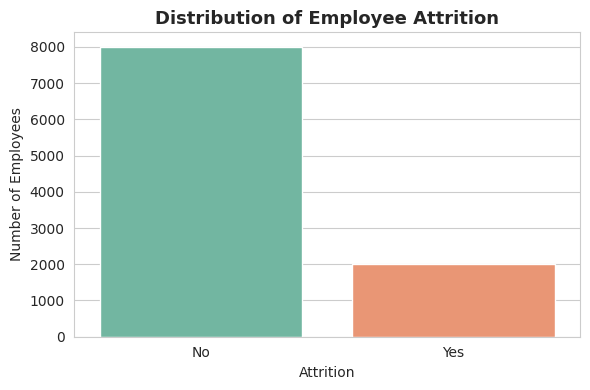

In [4]:

# 4.1 Attrition distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Attrition", hue="Attrition", palette="Set2", legend=False, ax=ax)
ax.set_title("Distribution of Employee Attrition", fontsize=13, fontweight="bold")
ax.set_xlabel("Attrition")
ax.set_ylabel("Number of Employees")
plt.tight_layout()
plt.show()


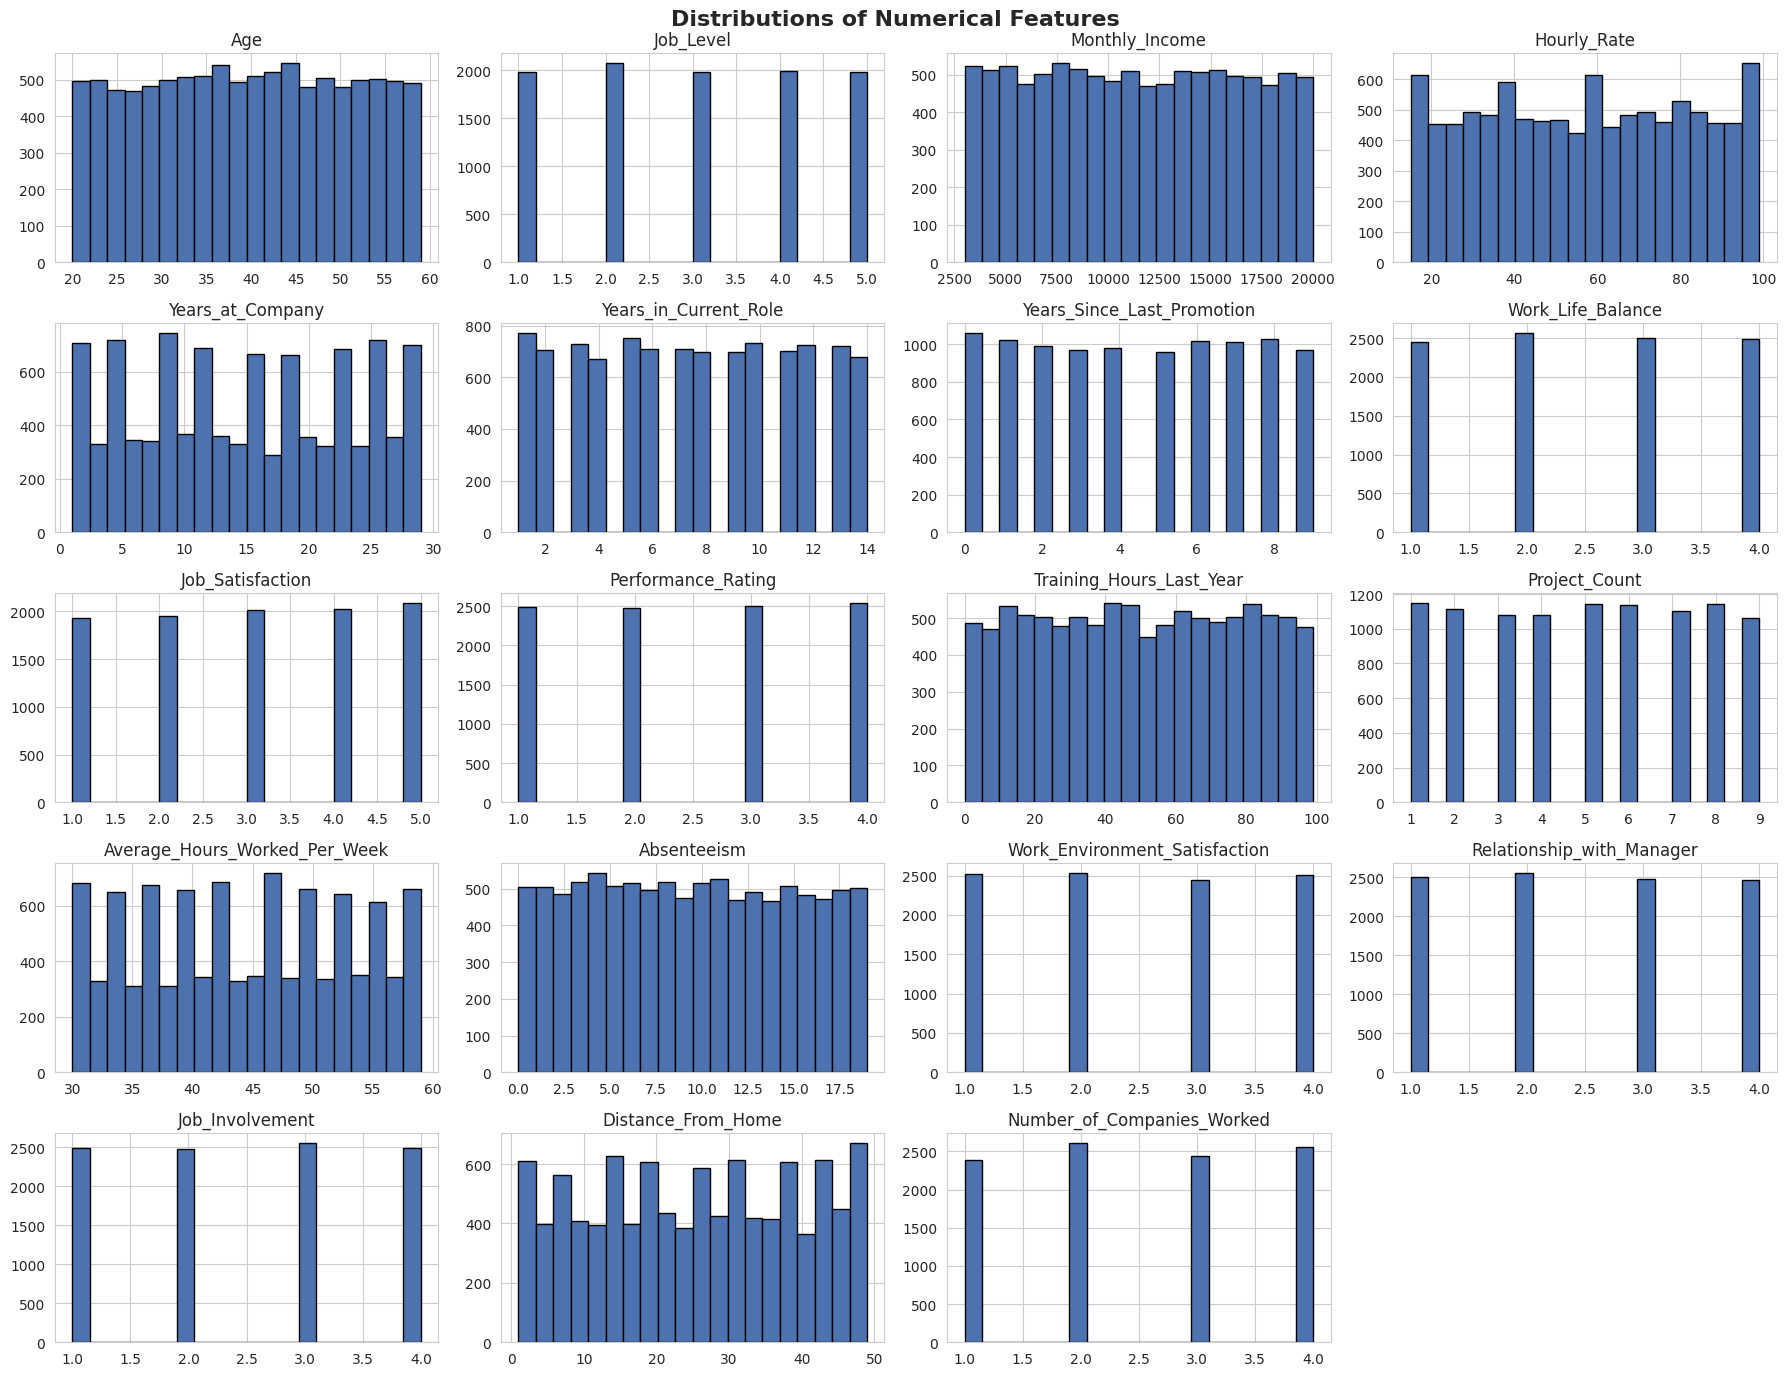

In [5]:

# 4.2 Numerical feature distributions
numerical_cols_preview = df.select_dtypes(include=[np.number]).columns.drop("Employee_ID")

df[numerical_cols_preview].hist(bins=20, figsize=(18, 14), color="#4C72B0", edgecolor="black")
plt.suptitle("Distributions of Numerical Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


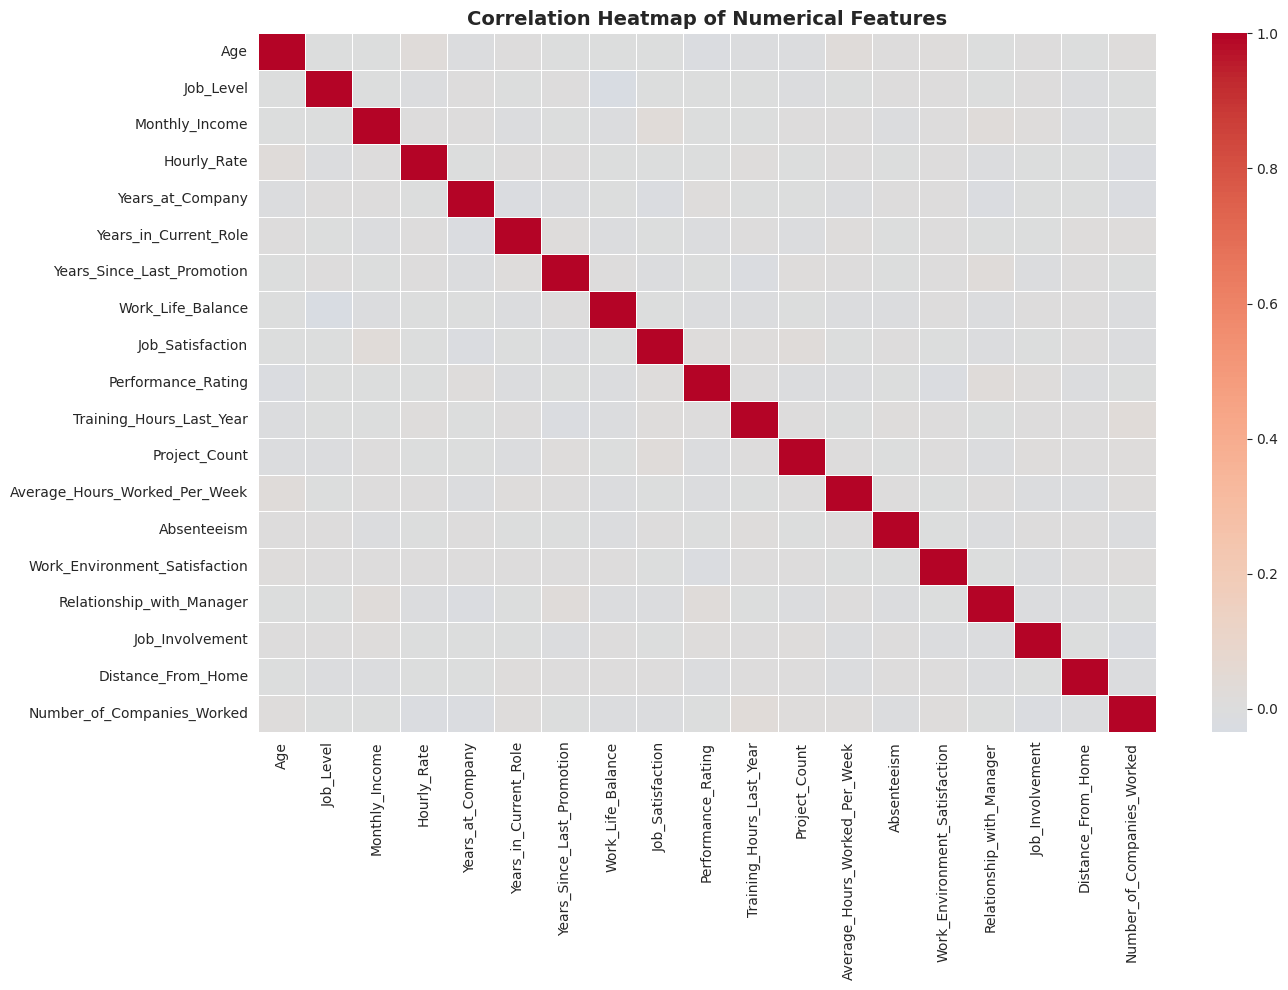

In [6]:

# 4.3 Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df[numerical_cols_preview].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5, center=0)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


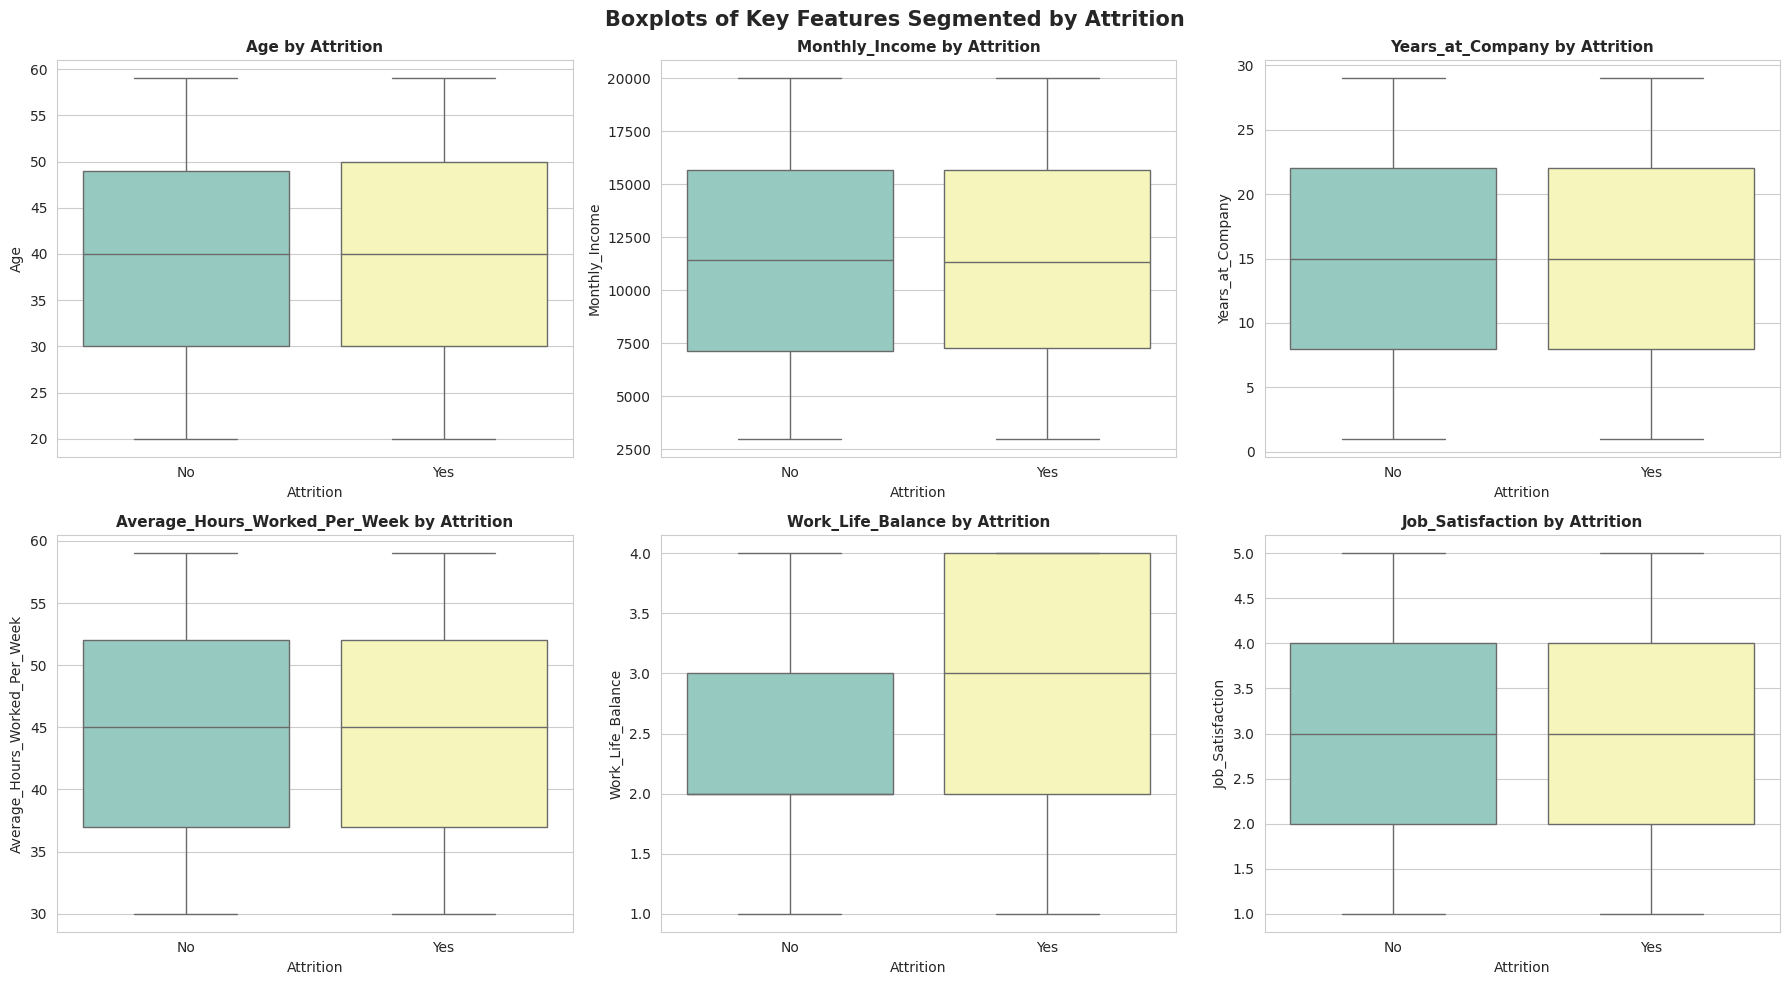

In [7]:

# 4.4 Boxplots - key numerical features vs Attrition
box_features = ["Age", "Monthly_Income", "Years_at_Company", "Average_Hours_Worked_Per_Week",
                 "Work_Life_Balance", "Job_Satisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(box_features):
    sns.boxplot(data=df, x="Attrition", y=feature, hue="Attrition", palette="Set3",
                legend=False, ax=axes[i])
    axes[i].set_title(f"{feature} by Attrition", fontsize=11, fontweight="bold")
plt.suptitle("Boxplots of Key Features Segmented by Attrition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


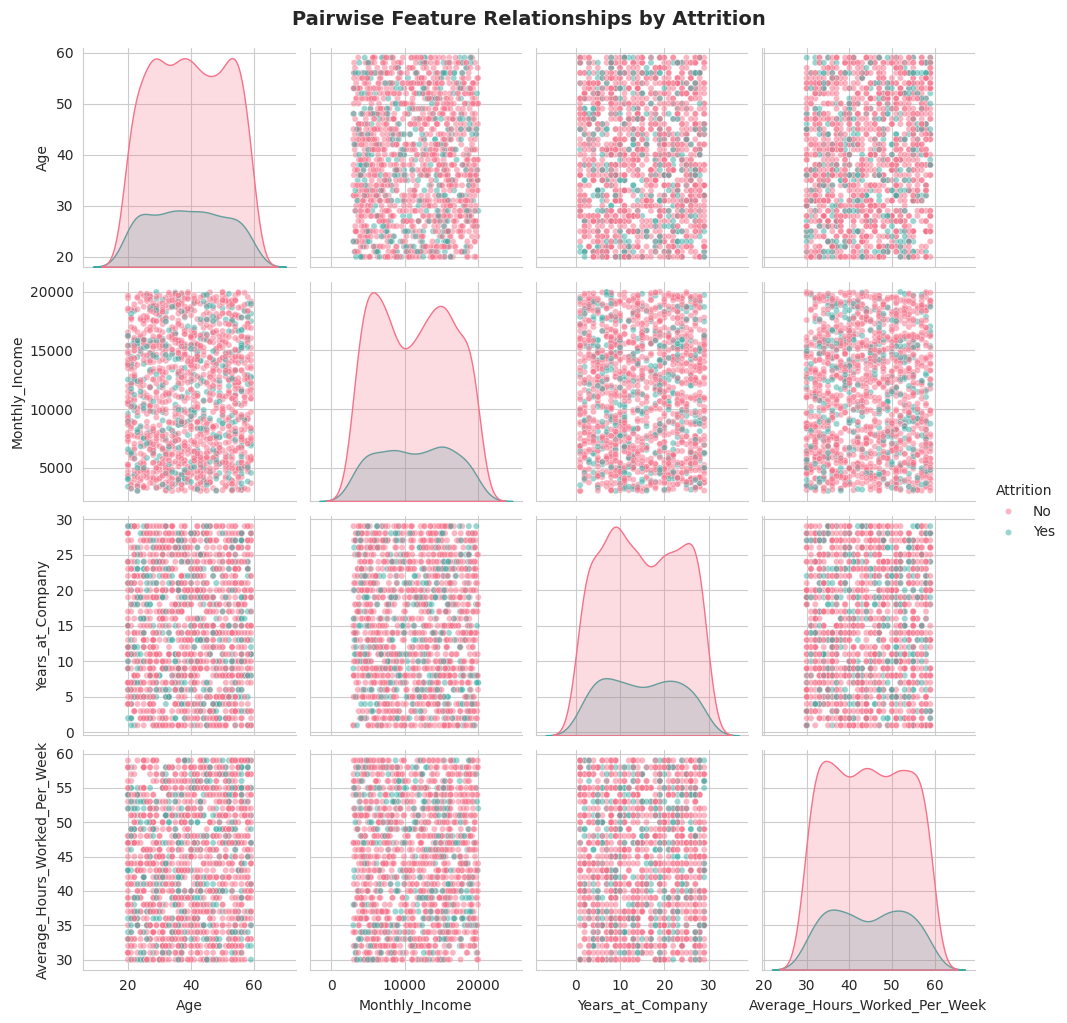

In [8]:

# 4.5 Feature relationships - scatter/pairplot on selected features
sample_df = df.sample(1500, random_state=RANDOM_STATE)
sns.pairplot(sample_df, vars=["Age", "Monthly_Income", "Years_at_Company", "Average_Hours_Worked_Per_Week"],
             hue="Attrition", palette="husl", plot_kws={"alpha": 0.5, "s": 20})
plt.suptitle("Pairwise Feature Relationships by Attrition", y=1.02, fontsize=14, fontweight="bold")
plt.show()


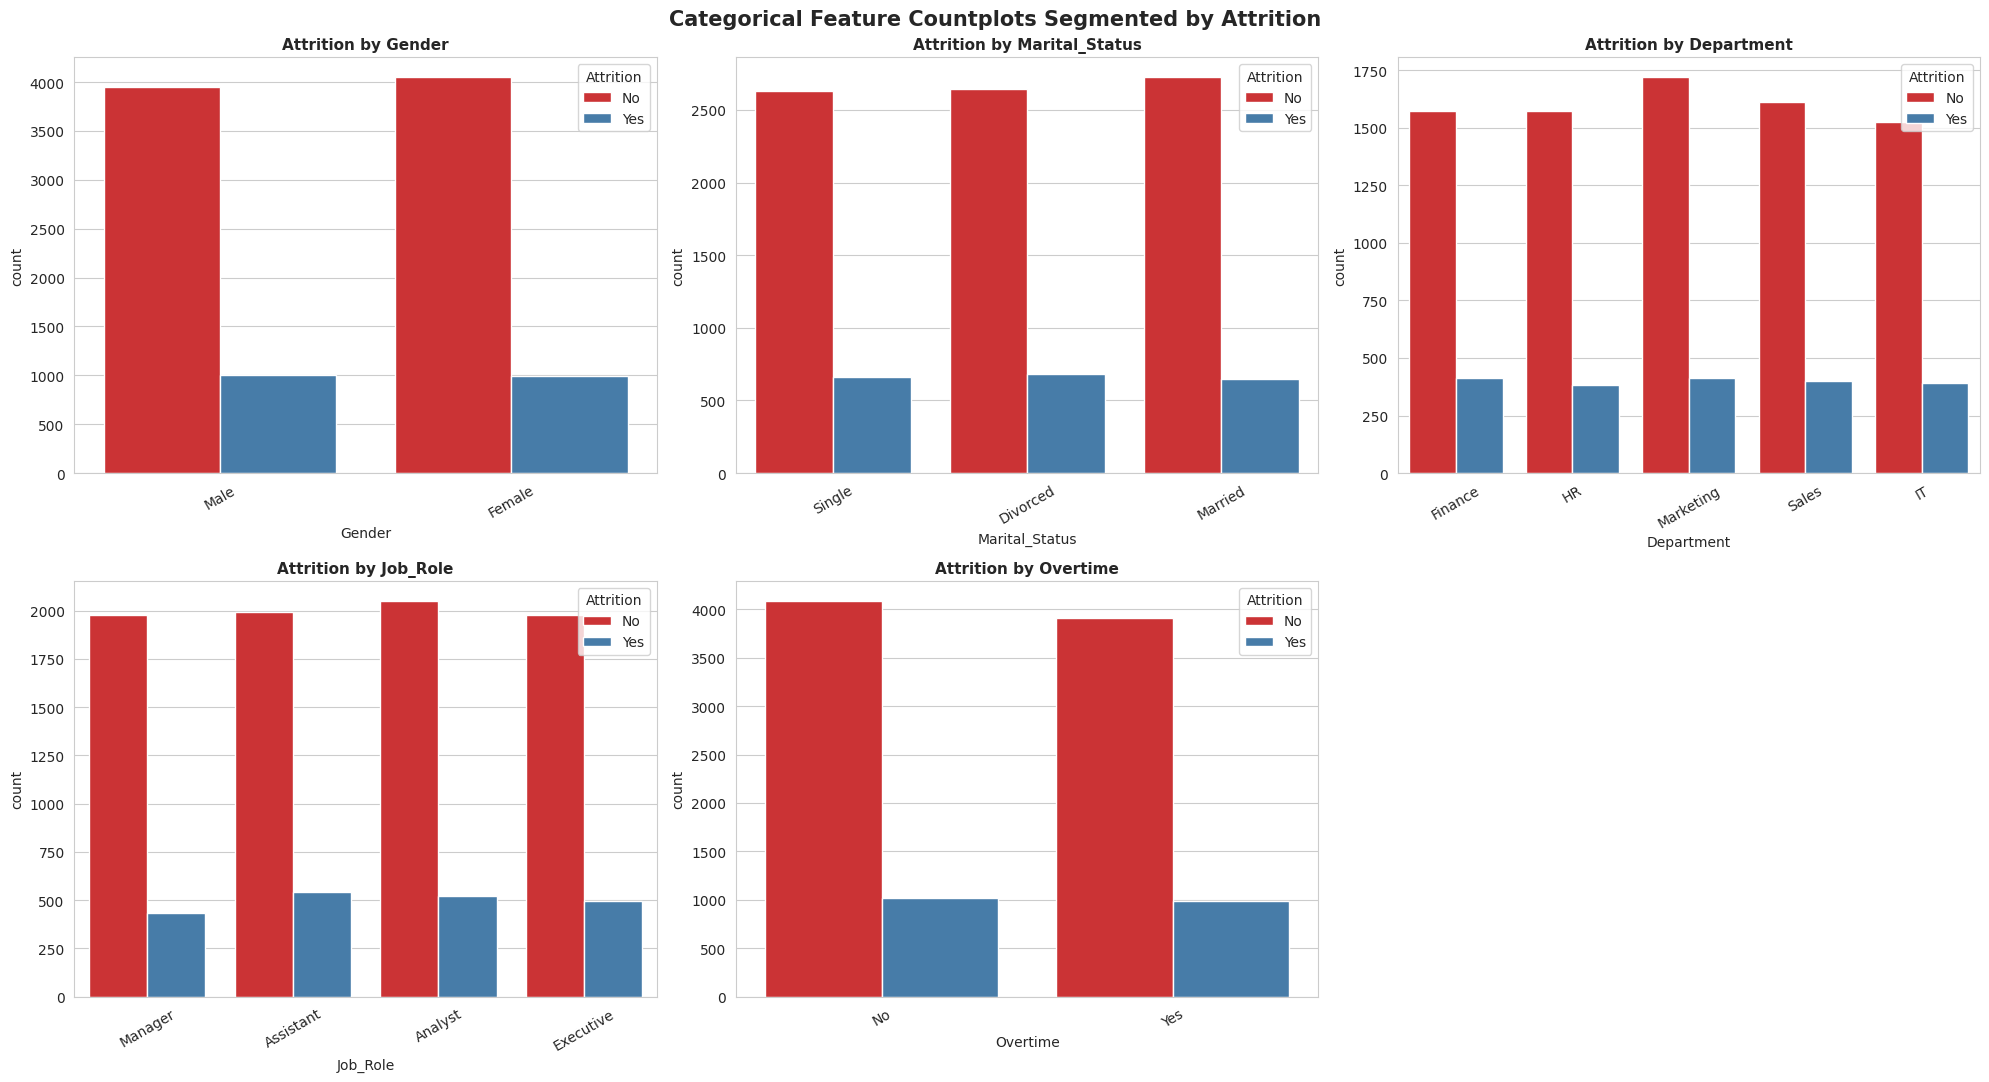

In [9]:

# 4.6 Countplots - categorical features vs Attrition
cat_features = ["Gender", "Marital_Status", "Department", "Job_Role", "Overtime"]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for i, feature in enumerate(cat_features):
    sns.countplot(data=df, x=feature, hue="Attrition", palette="Set1", ax=axes[i])
    axes[i].set_title(f"Attrition by {feature}", fontsize=11, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=30)
fig.delaxes(axes[-1])
plt.suptitle("Categorical Feature Countplots Segmented by Attrition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


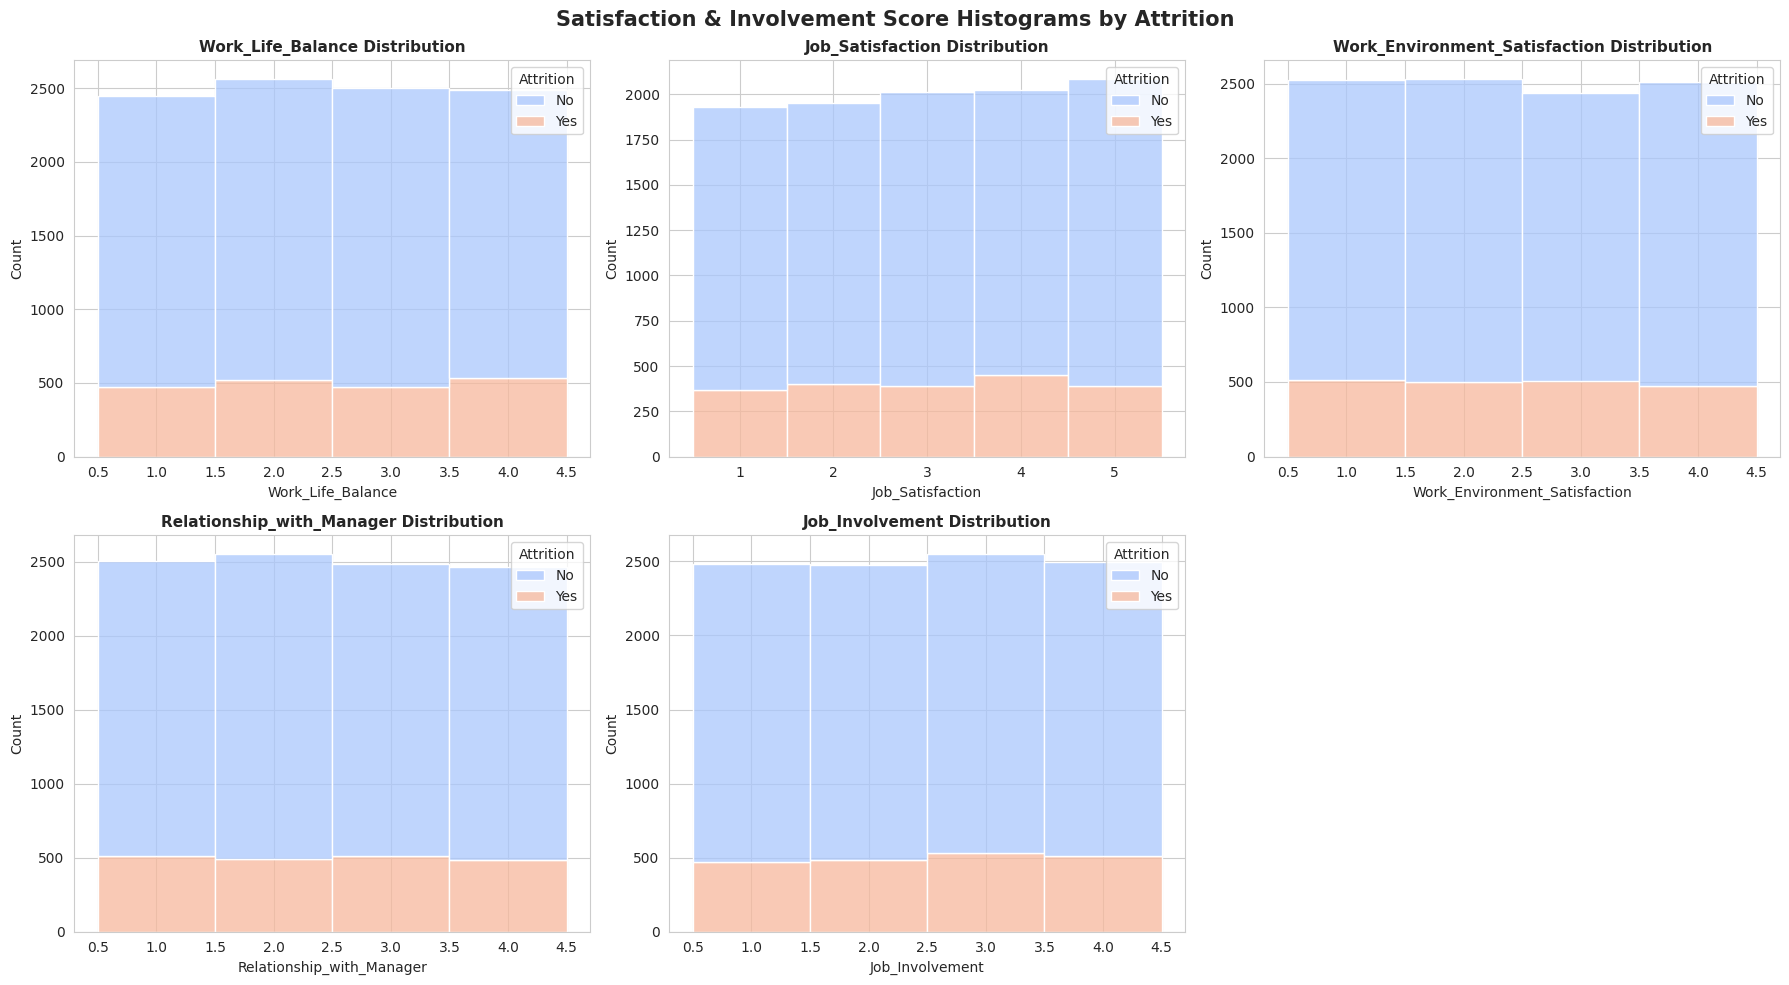

In [10]:

# 4.7 Histograms - Work-related satisfaction scores
satisfaction_cols = ["Work_Life_Balance", "Job_Satisfaction", "Work_Environment_Satisfaction",
                      "Relationship_with_Manager", "Job_Involvement"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(satisfaction_cols):
    sns.histplot(data=df, x=col, hue="Attrition", multiple="stack", palette="coolwarm",
                 discrete=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution", fontsize=11, fontweight="bold")
fig.delaxes(axes[-1])
plt.suptitle("Satisfaction & Involvement Score Histograms by Attrition", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Data Preprocessing

In [11]:

# Drop identifier column - it holds no predictive value
df_model = df.drop(columns=["Employee_ID"])

# Separate features (X) and target (y)
X = df_model.drop(columns=["Attrition"])
y = df_model["Attrition"].map({"No": 0, "Yes": 1})

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# Automatically detect categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("\nDetected categorical columns:", categorical_cols)
print("Detected numerical columns:", numerical_cols)

# Build preprocessing pipeline using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("\nColumnTransformer preprocessor created successfully.")


Feature matrix shape: (10000, 24)
Target vector shape: (10000,)

Detected categorical columns: ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']
Detected numerical columns: ['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']

ColumnTransformer preprocessor created successfully.


## 6. Train-Test Split

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training set shape: (8000, 24)
Testing set shape: (2000, 24)

Training target distribution:
Attrition
0    0.8
1    0.2
Name: proportion, dtype: float64

Testing target distribution:
Attrition
0    0.8
1    0.2
Name: proportion, dtype: float64


## 7. Train Four Models

In [13]:

# Every model is wrapped in a Pipeline with the SAME preprocessor - no duplicated
# preprocessing code, and the preprocessing step is refit correctly within each
# cross-validation fold.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
}

pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name} trained successfully.")


Logistic Regression trained successfully.


Random Forest trained successfully.


XGBoost trained successfully.
LightGBM trained successfully.


## 8. Evaluate Every Model

Model: Logistic Regression


Accuracy       : 0.8005
Precision      : 0.0000
Recall         : 0.0000
F1-score       : 0.0000
ROC-AUC        : 0.5058
5-Fold CV AUC  : 0.4903 (+/- 0.0172)

Classification Report:


              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



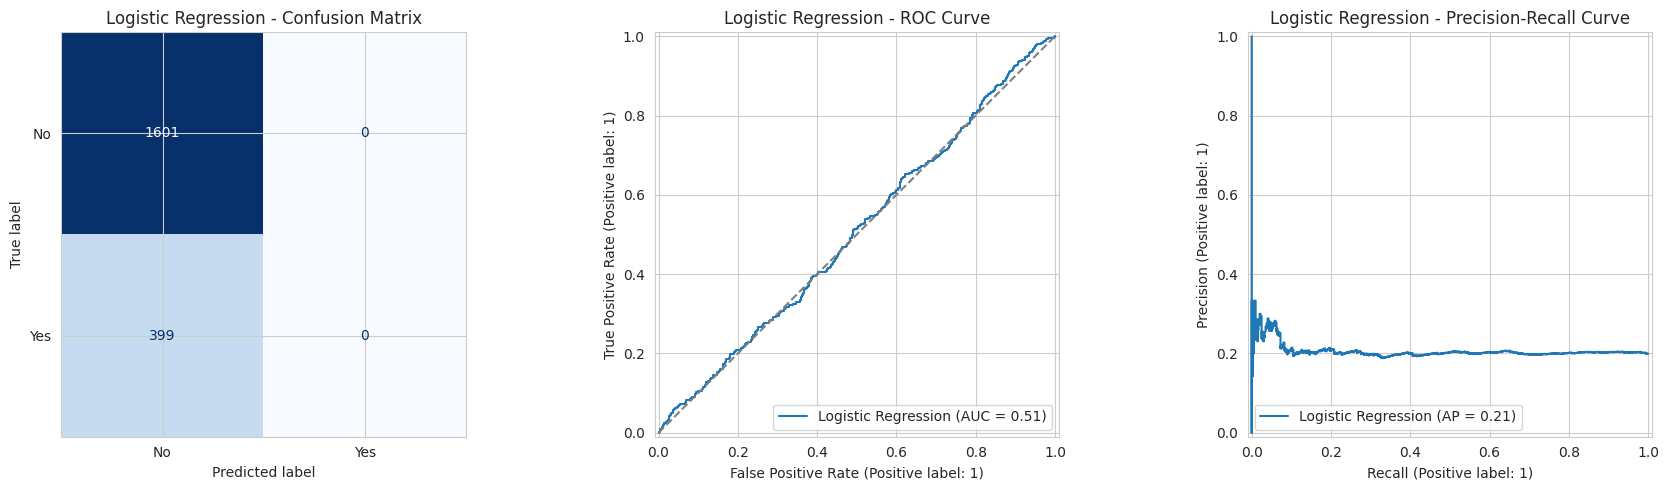

Model: Random Forest


Accuracy       : 0.8005
Precision      : 0.0000
Recall         : 0.0000
F1-score       : 0.0000
ROC-AUC        : 0.4873
5-Fold CV AUC  : 0.4932 (+/- 0.0240)

Classification Report:
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



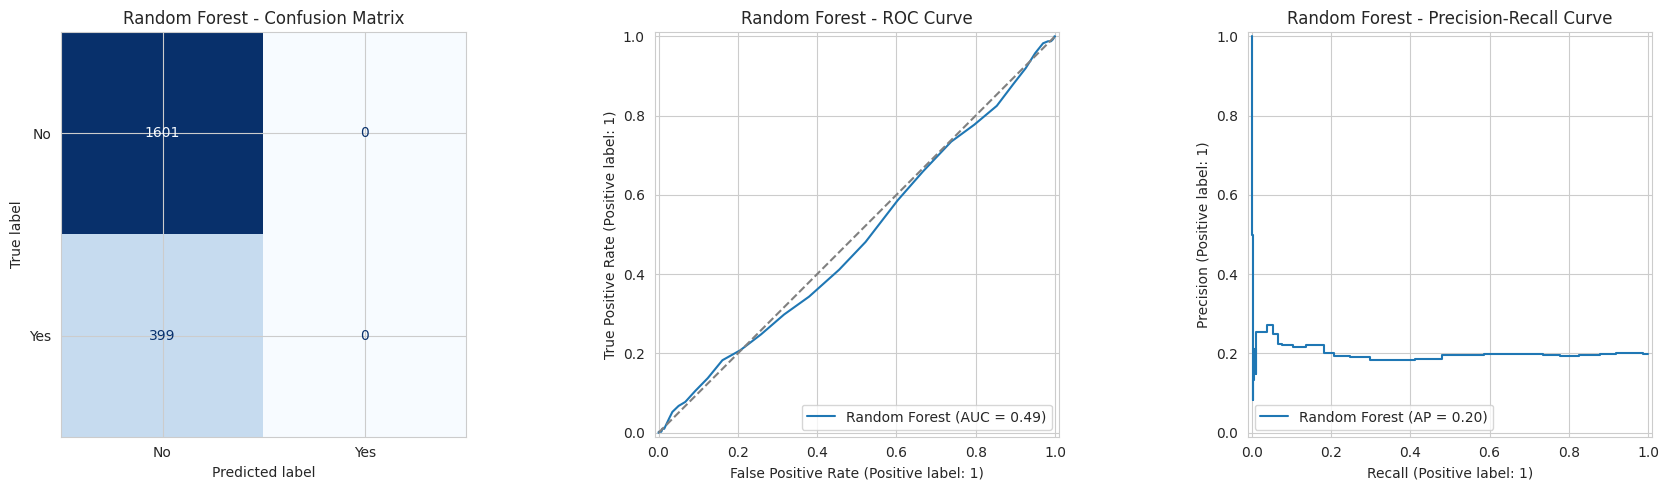

Model: XGBoost


Accuracy       : 0.7750
Precision      : 0.1852
Recall         : 0.0376
F1-score       : 0.0625
ROC-AUC        : 0.4948
5-Fold CV AUC  : 0.4976 (+/- 0.0145)

Classification Report:
              precision    recall  f1-score   support

          No       0.80      0.96      0.87      1601
         Yes       0.19      0.04      0.06       399

    accuracy                           0.78      2000
   macro avg       0.49      0.50      0.47      2000
weighted avg       0.68      0.78      0.71      2000



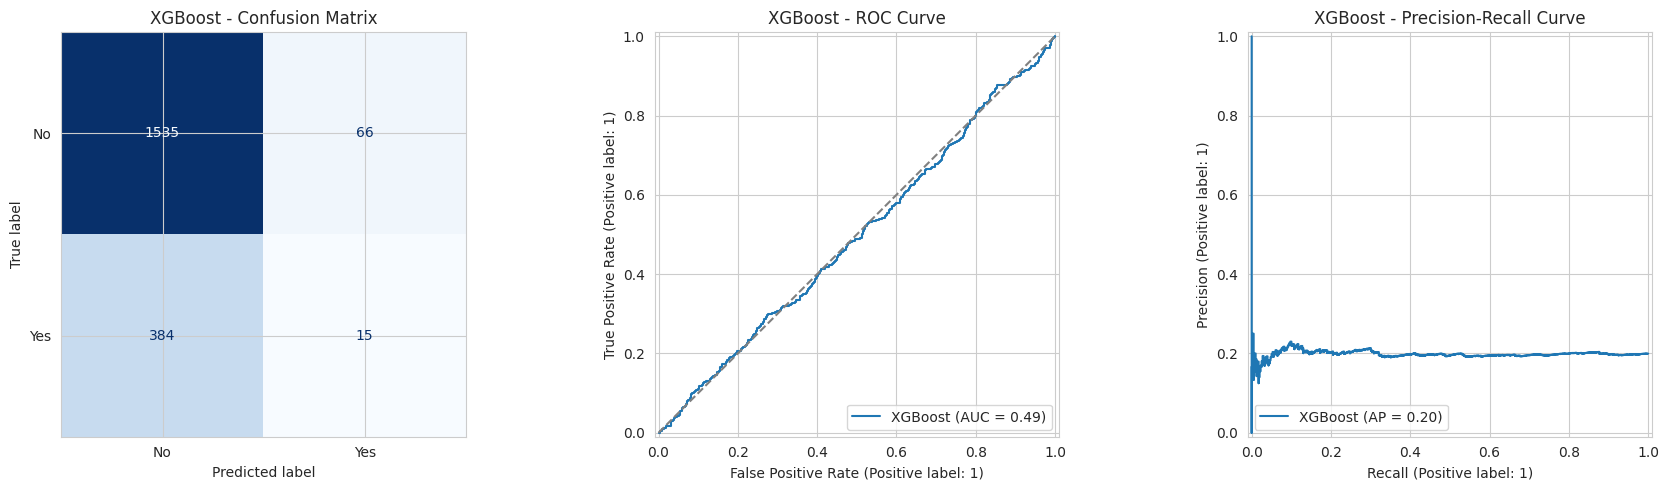

Model: LightGBM


Accuracy       : 0.7980
Precision      : 0.1429
Recall         : 0.0025
F1-score       : 0.0049
ROC-AUC        : 0.4707
5-Fold CV AUC  : 0.4958 (+/- 0.0105)

Classification Report:
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.14      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.47      0.50      0.45      2000
weighted avg       0.67      0.80      0.71      2000



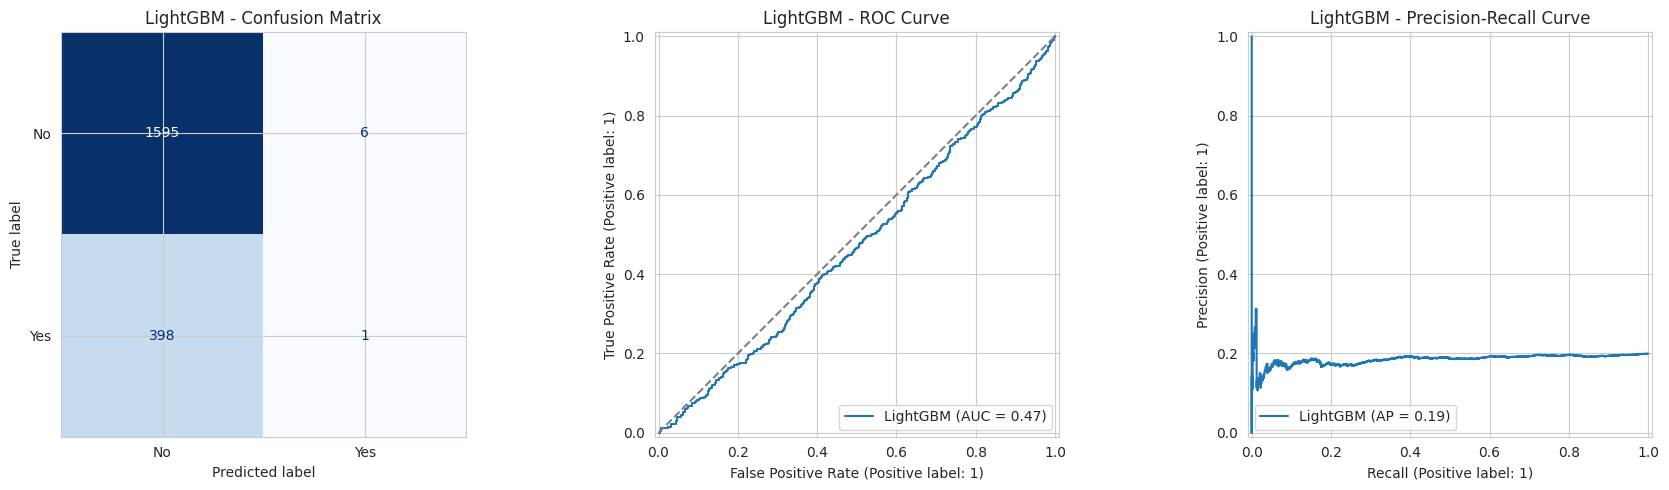

In [14]:

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}

for name, pipe in pipelines.items():
    print("=" * 70)
    print(f"Model: {name}")
    print("=" * 70)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)
    cv_mean = cv_scores.mean()

    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1,
        "ROC-AUC": roc_auc, "CV Mean ROC-AUC": cv_mean,
        "y_pred": y_pred, "y_proba": y_proba
    }

    print(f"Accuracy       : {acc:.4f}")
    print(f"Precision      : {prec:.4f}")
    print(f"Recall         : {rec:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"ROC-AUC        : {roc_auc:.4f}")
    print(f"5-Fold CV AUC  : {cv_mean:.4f} (+/- {cv_scores.std():.4f})")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

    # Confusion Matrix
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{name} - Confusion Matrix")

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=name)
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"{name} - ROC Curve")

    # Precision-Recall Curve
    PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], name=name)
    axes[2].set_title(f"{name} - Precision-Recall Curve")

    plt.tight_layout()
    plt.show()


## 9. Model Comparison

In [15]:

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["Accuracy"] for m in results],
    "Precision": [results[m]["Precision"] for m in results],
    "Recall": [results[m]["Recall"] for m in results],
    "F1-score": [results[m]["F1-score"] for m in results],
    "ROC-AUC": [results[m]["ROC-AUC"] for m in results],
    "Cross Validation Mean": [results[m]["CV Mean ROC-AUC"] for m in results],
})

comparison_df = comparison_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Cross Validation Mean
0,Logistic Regression,0.8005,0.000000,0.000000,0.000000,0.505779,0.490344
1,XGBoost,0.7750,0.185185,0.037594,0.062500,0.494772,0.497581
2,Random Forest,0.8005,0.000000,0.000000,0.000000,0.487256,0.493167
3,LightGBM,0.7980,0.142857,0.002506,0.004926,0.470741,0.495817


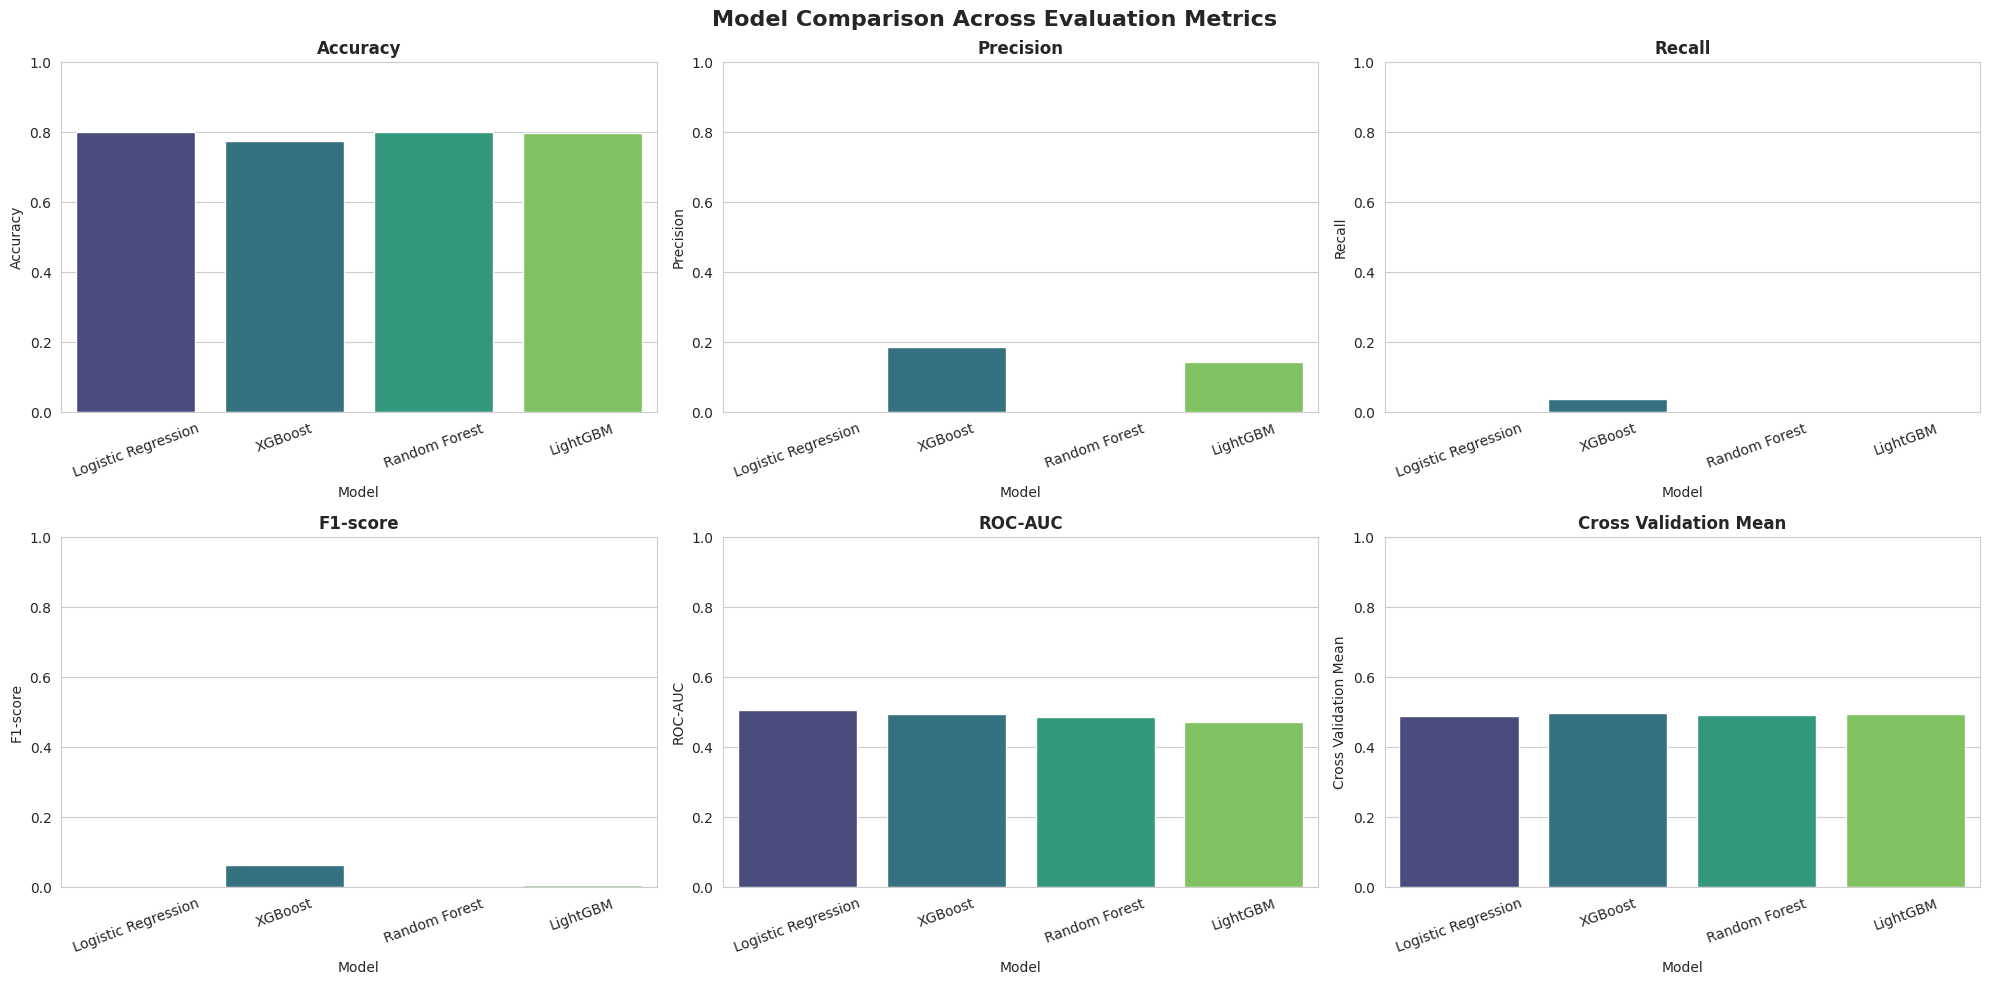

In [16]:

# Bar charts comparing models across all metrics
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Cross Validation Mean"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=comparison_df, x="Model", y=metric, hue="Model", palette="viridis",
                legend=False, ax=axes[i])
    axes[i].set_title(metric, fontsize=12, fontweight="bold")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=20)

plt.suptitle("Model Comparison Across Evaluation Metrics", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Select Best Model

In [17]:

best_model_name = comparison_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]

print("=" * 70)
print(f"BEST MODEL (by ROC-AUC): {best_model_name}")
print("=" * 70)
print(comparison_df.iloc[0])


BEST MODEL (by ROC-AUC): Logistic Regression
Model                    Logistic Regression
Accuracy                              0.8005
Precision                                0.0
Recall                                   0.0
F1-score                                 0.0
ROC-AUC                             0.505779
Cross Validation Mean               0.490344
Name: 0, dtype: object


## 11. Hyperparameter Tuning (Best Model Only)

In [18]:

# Define reasonable search spaces per model type
param_distributions = {
    "Logistic Regression": {
        "classifier__C": np.logspace(-3, 2, 20),
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs", "liblinear"]
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300, 400, 500],
        "classifier__max_depth": [None, 5, 10, 15, 20],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2", None]
    },
    "XGBoost": {
        "classifier__n_estimators": [100, 200, 300, 400],
        "classifier__max_depth": [3, 4, 5, 6, 8],
        "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.6, 0.8, 1.0],
        "classifier__colsample_bytree": [0.6, 0.8, 1.0]
    },
    "LightGBM": {
        "classifier__n_estimators": [100, 200, 300, 400],
        "classifier__num_leaves": [15, 31, 63, 127],
        "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "classifier__subsample": [0.6, 0.8, 1.0],
        "classifier__colsample_bytree": [0.6, 0.8, 1.0]
    }
}

search_space = param_distributions[best_model_name]

random_search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=search_space,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)
print(f"\nBest Cross-Validated ROC-AUC Score: {random_search.best_score_:.4f}")

# Retrain final tuned model using best parameters
tuned_pipeline = random_search.best_estimator_
tuned_pipeline.fit(X_train, y_train)


Best Parameters:
{'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': np.float64(0.001)}

Best Cross-Validated ROC-AUC Score: 0.4909


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 12. Final Evaluation (Tuned Model)

In [19]:

y_pred_tuned = tuned_pipeline.predict(X_test)
y_proba_tuned = tuned_pipeline.predict_proba(X_test)[:, 1]

acc_t = accuracy_score(y_test, y_pred_tuned)
prec_t = precision_score(y_test, y_pred_tuned)
rec_t = recall_score(y_test, y_pred_tuned)
f1_t = f1_score(y_test, y_pred_tuned)
roc_auc_t = roc_auc_score(y_test, y_proba_tuned)
cv_scores_t = cross_val_score(tuned_pipeline, X_train, y_train, cv=cv_strategy, scoring="roc_auc", n_jobs=-1)

print(f"Tuned {best_model_name} - Final Test Performance")
print("-" * 50)
print(f"Accuracy       : {acc_t:.4f}")
print(f"Precision      : {prec_t:.4f}")
print(f"Recall         : {rec_t:.4f}")
print(f"F1-score       : {f1_t:.4f}")
print(f"ROC-AUC        : {roc_auc_t:.4f}")
print(f"5-Fold CV AUC  : {cv_scores_t.mean():.4f} (+/- {cv_scores_t.std():.4f})")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["No", "Yes"]))


Tuned Logistic Regression - Final Test Performance
--------------------------------------------------
Accuracy       : 0.8005
Precision      : 0.0000
Recall         : 0.0000
F1-score       : 0.0000
ROC-AUC        : 0.4912
5-Fold CV AUC  : 0.4909 (+/- 0.0161)

Classification Report:
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



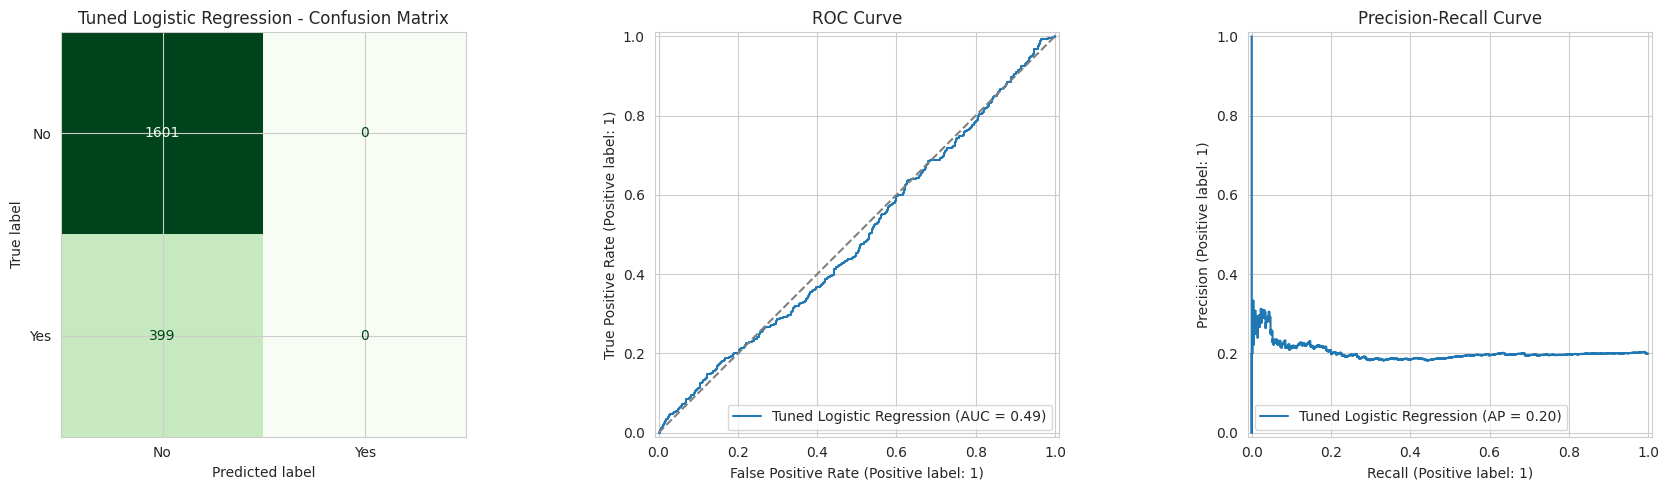

In [20]:

# Confusion Matrix, ROC Curve, Precision-Recall Curve for the tuned model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_t = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_t, display_labels=["No", "Yes"]).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title(f"Tuned {best_model_name} - Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba_tuned, ax=axes[1], name=f"Tuned {best_model_name}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba_tuned, ax=axes[2], name=f"Tuned {best_model_name}")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()


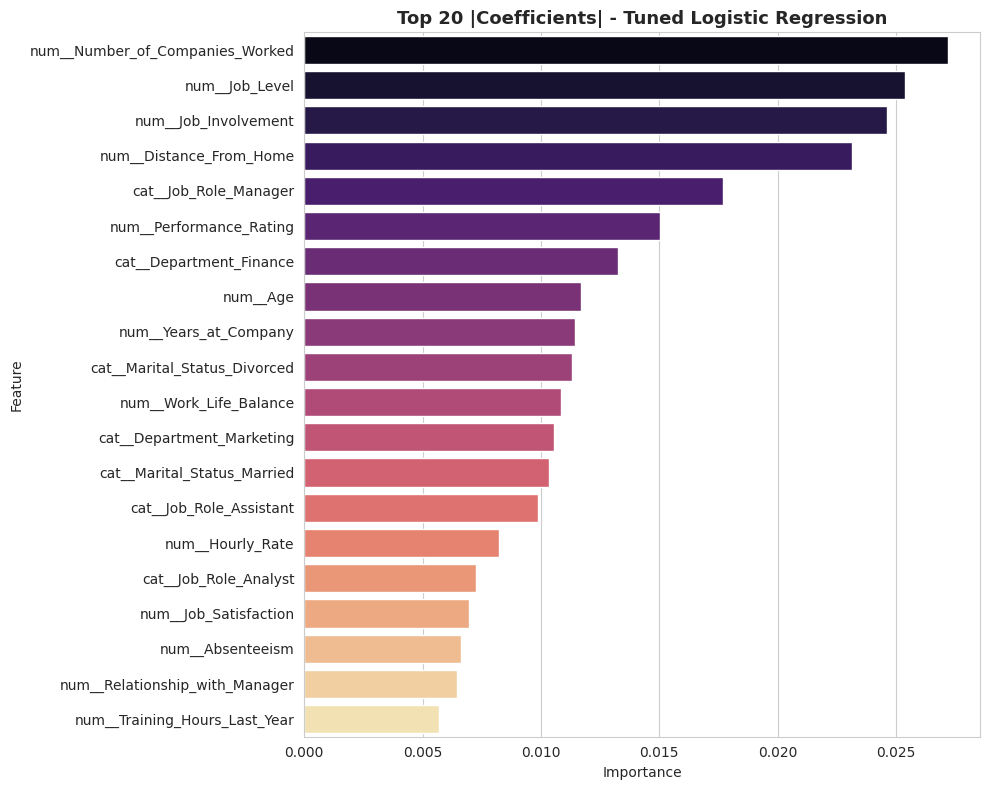

In [21]:

# Feature Importance (if supported by the tuned model)
classifier_step = tuned_pipeline.named_steps["classifier"]
feature_names = tuned_pipeline.named_steps["preprocessor"].get_feature_names_out()

if hasattr(classifier_step, "feature_importances_"):
    importances = classifier_step.feature_importances_
    fi_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    fi_df = fi_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df.head(20), x="Importance", y="Feature", hue="Feature",
                palette="magma", legend=False)
    plt.title(f"Top 20 Feature Importances - Tuned {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
elif hasattr(classifier_step, "coef_"):
    importances = np.abs(classifier_step.coef_[0])
    fi_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    fi_df = fi_df.sort_values(by="Importance", ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df.head(20), x="Importance", y="Feature", hue="Feature",
                palette="magma", legend=False)
    plt.title(f"Top 20 |Coefficients| - Tuned {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("This model does not expose feature importances or coefficients directly.")


## 13. Explainability (SHAP)

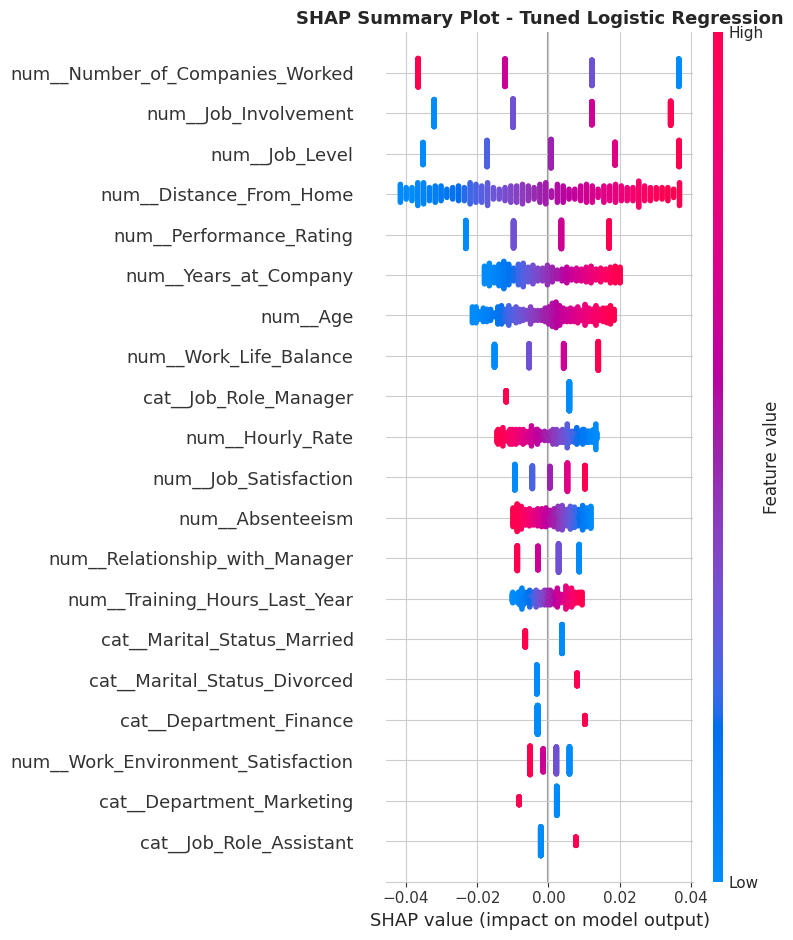

In [22]:

# Transform test data through the fitted preprocessor for SHAP
X_test_transformed = tuned_pipeline.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Use a manageable sample for SHAP computation speed
shap_sample = X_test_transformed_df.sample(min(500, len(X_test_transformed_df)), random_state=RANDOM_STATE)

tree_based_models = ("Random Forest", "XGBoost", "LightGBM")

if best_model_name in tree_based_models:
    explainer = shap.TreeExplainer(classifier_step)
    shap_values = explainer.shap_values(shap_sample)

    # For binary classifiers that return a list of arrays, select the positive class
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    shap.summary_plot(shap_values_plot, shap_sample, show=False)
    plt.title(f"SHAP Summary Plot - Tuned {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    # Fall back to a linear/kernel explainer for non-tree models (e.g. Logistic Regression)
    background = shap.sample(X_test_transformed_df, 100, random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(classifier_step, background)
    shap_values = explainer.shap_values(shap_sample)
    shap.summary_plot(shap_values, shap_sample, show=False)
    plt.title(f"SHAP Summary Plot - Tuned {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 14. Save Final Model

In [23]:

# Save the complete pipeline (preprocessing + tuned model) as a single object.
# No separate encoders or scalers are saved - everything is already inside the pipeline.
MODEL_PATH = "employee_attrition_model.pkl"
joblib.dump(tuned_pipeline, MODEL_PATH)
print(f"Final pipeline saved to '{MODEL_PATH}'")


Final pipeline saved to 'employee_attrition_model.pkl'


## 15. Verify Saved Model

In [24]:

# Reload the saved pipeline
loaded_pipeline = joblib.load(MODEL_PATH)

# Run predictions on a handful of test samples
sample_X = X_test.sample(5, random_state=RANDOM_STATE)
sample_y = y_test.loc[sample_X.index]

original_preds = tuned_pipeline.predict(sample_X)
reloaded_preds = loaded_pipeline.predict(sample_X)

verification_df = pd.DataFrame({
    "Actual": sample_y.map({0: "No", 1: "Yes"}).values,
    "Original Model Prediction": pd.Series(original_preds).map({0: "No", 1: "Yes"}).values,
    "Reloaded Model Prediction": pd.Series(reloaded_preds).map({0: "No", 1: "Yes"}).values
})

display(verification_df)

match = np.array_equal(original_preds, reloaded_preds)
print(f"\nPredictions from original and reloaded model match: {match}")


,Actual,Original Model Prediction,Reloaded Model Prediction
0,Yes,No,No
1,Yes,No,No
2,Yes,No,No
3,Yes,No,No
4,No,No,No



Predictions from original and reloaded model match: True


## Conclusion

This notebook delivered a complete, reproducible machine learning pipeline for employee attrition prediction. Four models were trained inside identical preprocessing pipelines, evaluated using multiple metrics and 5-fold cross-validation, compared, and the best-performing model was selected, tuned via `RandomizedSearchCV`, explained with SHAP, and persisted as a single deployable artefact (`employee_attrition_model.pkl`) for use in the accompanying Streamlit application.